In [1]:
import io
import pandas as pd

# 1. Instalar liac-arff que maneja mucho mejor los caracteres '?' de Weka
!pip install liac-arff -q
import arff

In [2]:
ruta_archivo = '/content/sample_data/chronic_kidney_disease.arff'

In [3]:
import pandas as pd

# 1. Definir la ruta exacta del archivo
ruta_archivo = "/content/chronic_kidney_disease.arff"

# Nombres oficiales de las 25 columnas del dataset renal
columnas = [
    "age",
    "bp",
    "sg",
    "al",
    "su",
    "rbc",
    "pc",
    "pcc",
    "ba",
    "bgr",
    "bu",
    "sc",
    "sod",
    "pot",
    "hemo",
    "pcv",
    "wbcc",
    "rbcc",
    "htn",
    "dm",
    "cad",
    "appet",
    "pe",
    "ane",
    "class",
]

# 2. Leer el archivo con Pandas manejando líneas con errores
try:
    df = pd.read_csv(
        ruta_archivo,
        skiprows=29,  # Se salta las definiciones de atributos y la línea @data
        header=None,  # No usamos la primera fila como cabecera
        names=columnas,  # Asignamos los nombres correctos
        na_values="?",  # Transforma automáticamente los '?' en valores nulos (NaN)
        skipinitialspace=True,  # Elimina espacios después de las comas
        on_bad_lines="skip",  # SOLUCIÓN: Salta las líneas que tengan columnas de más o de menos
    )
    print("¡Archivo cargado con éxito!")
    print(
        f"Dimensiones finales: {df.shape[0]} filas y {df.shape[1]} columnas."
    )

    # 3. Mostrar las primeras filas (solo si df se creó con éxito)
    print("\nVista previa de los datos:")
    print(df.head())

except FileNotFoundError:
    print(
        f"Error: No se encontró el archivo en la ruta '{ruta_archivo}'. "
        "Revisa si termina en '.arff' o '.txt' en tu panel izquierdo."
    )
except Exception as e:
    print(f"Ocurrió un error inesperado al leer el archivo: {e}")

¡Archivo cargado con éxito!
Dimensiones finales: 397 filas y 25 columnas.

Vista previa de los datos:
    age    bp     sg   al   su     rbc        pc         pcc          ba  \
0  48.0  80.0  1.020  1.0  0.0     NaN    normal  notpresent  notpresent   
1   7.0  50.0  1.020  4.0  0.0     NaN    normal  notpresent  notpresent   
2  62.0  80.0  1.010  2.0  3.0  normal    normal  notpresent  notpresent   
3  48.0  70.0  1.005  4.0  0.0  normal  abnormal     present  notpresent   
4  51.0  80.0  1.010  2.0  0.0  normal    normal  notpresent  notpresent   

     bgr  ...  pcv  wbcc  rbcc  htn   dm cad appet   pe  ane class  
0  121.0  ...   44  7800   5.2  yes  yes  no  good   no   no   ckd  
1    NaN  ...   38  6000   NaN   no   no  no  good   no   no   ckd  
2  423.0  ...   31  7500   NaN   no  yes  no  poor   no  yes   ckd  
3  117.0  ...   32  6700   3.9  yes   no  no  poor  yes  yes   ckd  
4  106.0  ...   35  7300   4.6   no   no  no  good   no   no   ckd  

[5 rows x 25 columns]


In [4]:
import io
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats

# Definición de la ruta del archivo local
ruta_archivo = "/content/chronic_kidney_disease.arff"

# Nombres oficiales de las 25 columnas mapeadas según la documentación
columnas = [
    "age",
    "bp",
    "sg",
    "al",
    "su",
    "rbc",
    "pc",
    "pcc",
    "ba",
    "bgr",
    "bu",
    "sc",
    "sod",
    "pot",
    "hemo",
    "pcv",
    "wbcc",
    "rbcc",
    "htn",
    "dm",
    "cad",
    "appet",
    "pe",
    "ane",
    "class",
]

# Carga de datos convirtiendo el caracter "?" en valores nulos (NaN)
df = pd.read_csv(
    ruta_archivo,
    skiprows=29,
    header=None,
    names=columnas,
    na_values="?",
    skipinitialspace=True,
    on_bad_lines="skip",
)

# Corrección de tipos de datos que se leyeron como texto debido a espacios
df["pcv"] = pd.to_numeric(df["pcv"], errors="coerce")
df["wbcc"] = pd.to_numeric(df["wbcc"], errors="coerce")
df["rbcc"] = pd.to_numeric(df["rbcc"], errors="coerce")

# Limpieza de valores categóricos con espacios ocultos (ej. 'yes\t', 'no\t')
for col in df.select_dtypes(include=["object"]).columns:
    df[col] = df[col].astype(str).str.strip().str.replace(r"\t", "", regex=True)
    df.loc[df[col] == "nan", col] = np.nan

print(f"Dataset cargado con {df.shape[0]} filas y {df.shape[1]} columnas.")

Dataset cargado con 397 filas y 25 columnas.


In [5]:
variables_num = ["age", "bp", "hemo", "bgr", "bu", "sc"]
print(df[variables_num].describe().T[["mean", "50%", "std", "min", "max"]])

            mean    50%        std   min    max
age    51.456186   54.5  17.133935   2.0   90.0
bp     76.467532   80.0  13.711674  50.0  180.0
hemo   12.520870   12.6   2.917514   3.1   17.8
bgr   147.864407  121.0  79.290292  22.0  490.0
bu     57.608995   42.0  50.651072   1.5  391.0
sc      3.088289    1.3   5.760989   0.4   76.0


In [6]:
frec_abs = df["class"].value_counts(dropna=False)
frec_rel = df["class"].value_counts(normalize=True, dropna=False) * 100
print(
    pd.DataFrame(
        {"Frecuencia Absoluta": frec_abs, "Frecuencia Relativa (%)": frec_rel}
    )
)

        Frecuencia Absoluta  Frecuencia Relativa (%)
class                                               
ckd                     248                62.468514
notckd                  149                37.531486


/tmp/ipykernel_18228/2610500926.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="class", data=df, ax=axes[1], palette="Set2")


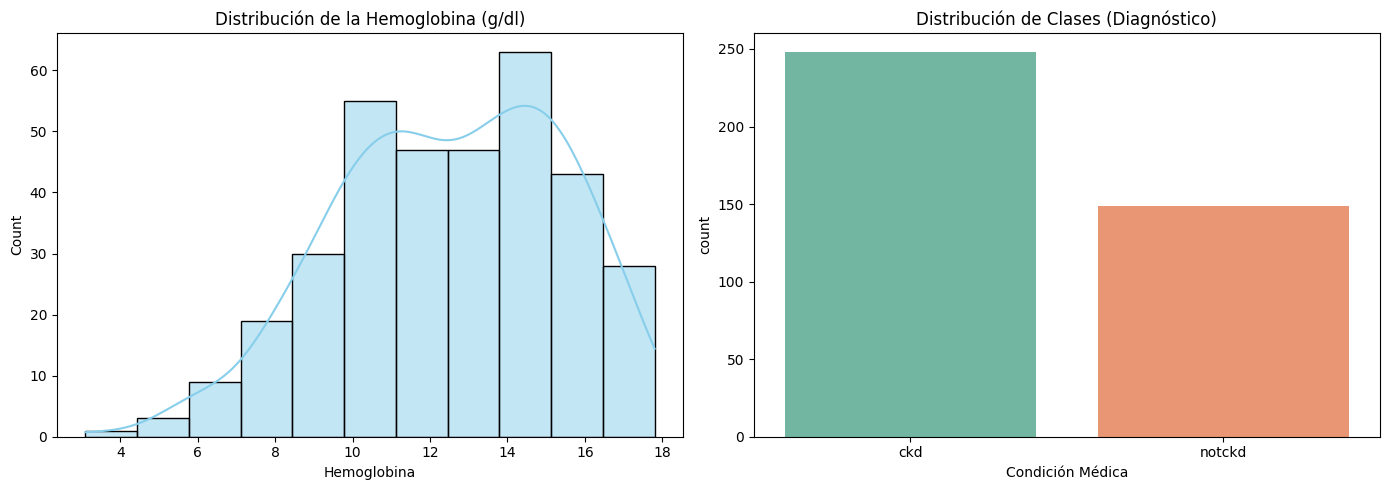

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograma de la Hemoglobina
sns.histplot(df["hemo"].dropna(), kde=True, ax=axes[0], color="skyblue")
axes[0].set_title("Distribución de la Hemoglobina (g/dl)")
axes[0].set_xlabel("Hemoglobina")

# Gráfico de Barras para la variable objetivo
sns.countplot(x="class", data=df, ax=axes[1], palette="Set2")
axes[1].set_title("Distribución de Clases (Diagnóstico)")
axes[1].set_xlabel("Condición Médica")

plt.tight_layout()
plt.show()

/tmp/ipykernel_18228/368163223.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="class", y="hemo", data=df, palette="Pastel1")


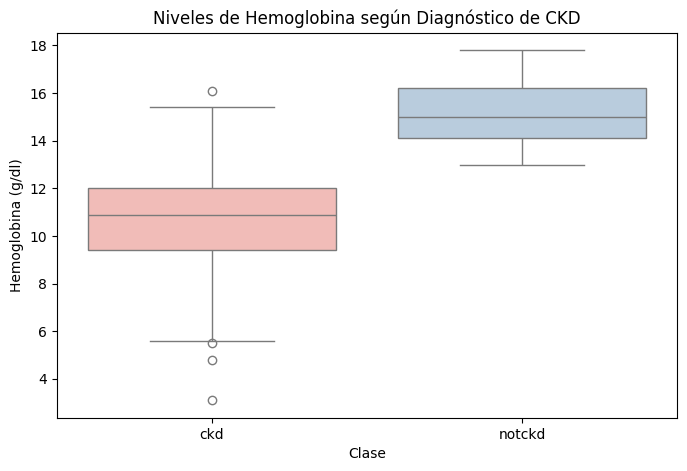

In [8]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="class", y="hemo", data=df, palette="Pastel1")
plt.title("Niveles de Hemoglobina según Diagnóstico de CKD")
plt.xlabel("Clase")
plt.ylabel("Hemoglobina (g/dl)")
plt.show()

In [9]:
import scipy.stats as stats

# Variables numéricas relevantes para la estimación
variables_estimar = ["age", "bp", "hemo"]

print("--- RESULTADOS DE ESTIMACIÓN DE PARÁMETROS (IC 95%) ---")

for var in variables_estimar:
    # Eliminamos nulos para el cálculo estadístico de cada variable
    datos_limpios = df[var].dropna()

    n = len(datos_limpios)
    media_muestral = datos_limpios.mean()
    error_estandar = stats.sem(datos_limpios)  # Errores estándar de la media

    # Construcción del intervalo de confianza utilizando la distribución t de Student
    ic_inferior, ic_superior = stats.t.interval(
        0.95, df=n - 1, loc=media_muestral, scale=error_estandar
    )

    # IMPRESIÓN CORREGIDA (Únicamente la f antes de las comillas)
    print(f"\nVariable: {var.upper()} (n válido = {n})")
    print(f"  Estimación Puntual (Media): {media_muestral:.3f}")
    print(f"  Intervalo de Confianza al 95%: [{ic_inferior:.3f}, {ic_superior:.3f}]")

--- RESULTADOS DE ESTIMACIÓN DE PARÁMETROS (IC 95%) ---

Variable: AGE (n válido = 388)
  Estimación Puntual (Media): 51.456
  Intervalo de Confianza al 95%: [49.746, 53.166]

Variable: BP (n válido = 385)
  Estimación Puntual (Media): 76.468
  Intervalo de Confianza al 95%: [75.094, 77.842]

Variable: HEMO (n válido = 345)
  Estimación Puntual (Media): 12.521
  Intervalo de Confianza al 95%: [12.212, 12.830]


In [10]:
grupo_ckd = df[df["class"] == "ckd"]["hemo"].dropna()
grupo_notckd = df[df["class"] == "notckd"]["hemo"].dropna()

t_stat, p_val = stats.ttest_ind(grupo_ckd, grupo_notckd, equal_var=False)
print(f"Prueba 1 - Estadístico t: {t_stat:.4f}, p-valor: {p_val:.4e}")

Prueba 1 - Estadístico t: -24.5765, p-valor: 8.6433e-77


In [11]:
# Creación de la tabla de contingencia
tabla_contingencia = pd.crosstab(df["htn"], df["class"])
chi2_stat, p_val_chi2, dof, expected = stats.chi2_contingency(
    tabla_contingencia
)

print("Tabla de contingencia observada:")
print(tabla_contingencia)
print(
    f"\nPrueba 2 - Estadístico Chi2: {chi2_stat:.4f}, p-valor: {p_val_chi2:.4e}"
)

Tabla de contingencia observada:
class  ckd  notckd
htn               
no     102     147
yes    146       0

Prueba 2 - Estadístico Chi2: 134.7678, p-valor: 3.7112e-31
